# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: <StringArray>
[ 'United States',          'China',          'India',        'Germany',
 'United Kingdom',         'France',         'Brazil',          'Japan',
         'Canada',      'Australia',    'South Korea',         'Russia',
   'South Africa',         'Mexico',      'Indonesia']
Length: 15, dtype: str

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


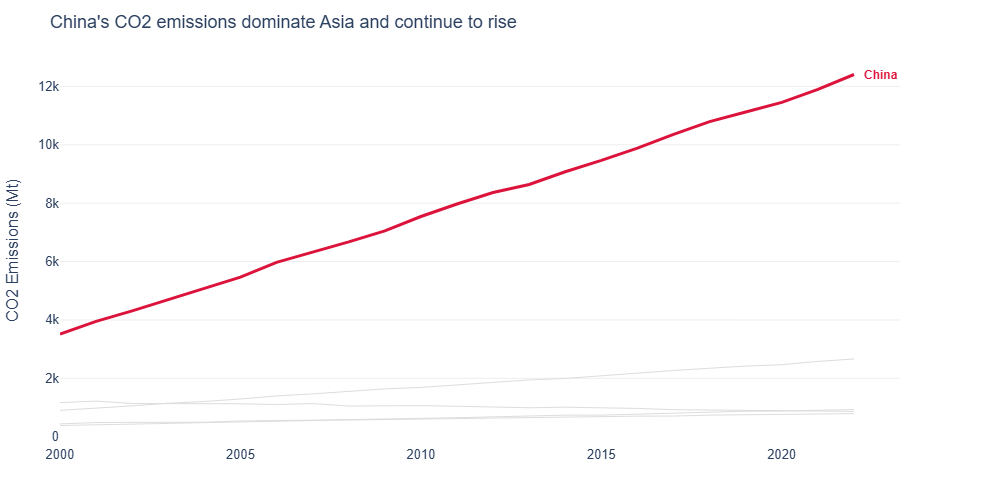

In [3]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE

asian = df[df["Region"] == "Asia"].copy()
highlight = "China"

color_map = {
    country: ("crimson" if country == highlight else "#DDDDDD")
    for country in asian["Country"].unique()
}

fig = px.line(
    asian.sort_values("Year"),
    x="Year",
    y="CO2_Mt",
    color="Country",
    color_discrete_map=color_map,
    title="China's CO2 emissions dominate Asia and continue to rise",
    labels={
        "CO2_Mt": "CO2 Emissions (Mt)",
        "Year": ""
    }
)

for trace in fig.data:
    trace.showlegend = False
    trace.line.width = 3 if trace.name == highlight else 1

last = asian[
    (asian["Country"] == highlight) &
    (asian["Year"] == asian["Year"].max())
]

fig.add_annotation(
    x=last["Year"].values[0],
    y=last["CO2_Mt"].values[0],
    text=f"<b>{highlight}</b>",
    showarrow=False,
    xanchor="left",
    xshift=8,
    font=dict(color="crimson", size=12, family="Arial")
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=13),
    yaxis=dict(gridcolor="#EEEEEE"),
    xaxis=dict(showgrid=False),
    margin=dict(l=60, r=100, t=55, b=40),
    height=500,
    width=1000
)

fig.show(renderer="png")

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


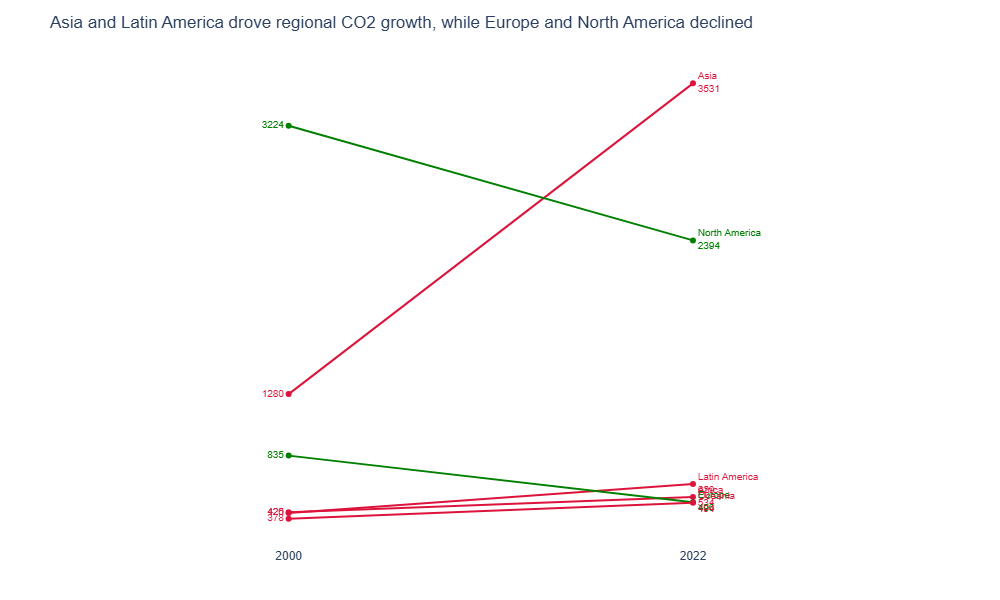

In [4]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE

reg = (
    df[df["Year"].isin([2000, 2022])]
    .groupby(["Region", "Year"])["CO2_Mt"]
    .mean()
    .reset_index()
)

changes = reg.groupby("Region")["CO2_Mt"].agg(["first", "last"])

color_map = {
    region: ("crimson" if row["last"] > row["first"] else "green")
    for region, row in changes.iterrows()
}

fig = px.line(
    reg.sort_values("Year"),
    x="Year",
    y="CO2_Mt",
    color="Region",
    color_discrete_map=color_map,
    markers=True,
    labels={
        "CO2_Mt": "",
        "Year": ""
    }
)

for region in changes.index:
    d = reg[reg["Region"] == region].sort_values("Year")

    fig.update_traces(
        selector=dict(name=region),
        mode="lines+markers+text",
        text=[
            f'{d["CO2_Mt"].iloc[0]:.0f}',
            f'{region}<br>{d["CO2_Mt"].iloc[1]:.0f}'
        ],
        textposition=["middle left", "middle right"],
        textfont=dict(size=10, color=color_map[region], family="Arial"),
        showlegend=False
    )

fig.update_layout(
    title="Asia and Latin America drove regional CO2 growth, while Europe and North America declined",
    xaxis=dict(
        tickvals=[2000, 2022],
        ticktext=["2000", "2022"],
        showgrid=False,
        range=[1993, 2030]
    ),
    yaxis=dict(
        showgrid=False,
        showticklabels=False,
        title=""
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=12),
    margin=dict(l=160, r=160, t=55, b=40),
    height=600,
    width=1000
)

fig.show(renderer="png")